In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as spo

In [11]:
def machnumber_norad(x):
    if np.abs(x)>1:
        M = 1
    else:
        f = lambda M: 2*np.arctan(M)-M-(0.5*np.pi-1)*np.abs(x)
        M = spo.root_scalar(f,bracket=[0,1]).root
    if x<0:
        return -M
    return M

def machnumber_rad(x):
    M = np.zeros_like(x)
    good = (x>=-1)&(x<=1)

    theta = np.angle(-x[good] + 1.j*np.sqrt(1-x[good]**2))
    M[good] = np.sqrt(3)*np.sin(theta/3)-np.cos(theta/3)
    M[x>1] = 1
    M[x<-1] = 1

    return M

def n_norad(M):
    return 1/(1+M**2)

def n_rad(M):
    return np.exp(-0.5*M**2)

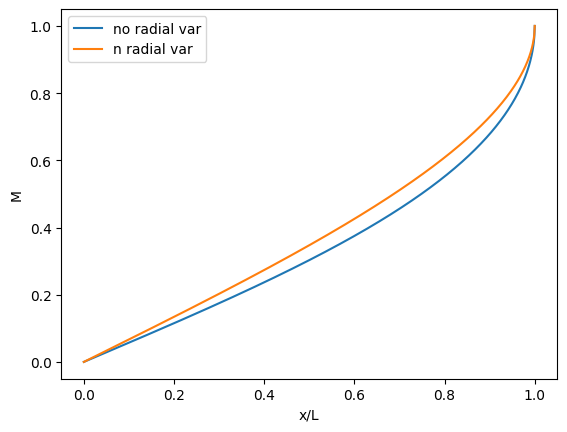

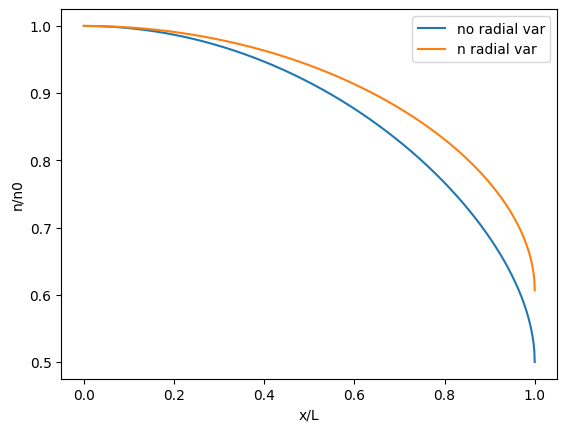

In [14]:
x = np.linspace(0,1,1000)
Mnorad = np.zeros_like(x)

for i in range(x.size):
    Mnorad[i] = machnumber_norad(x[i])

Mrad = machnumber_rad(x)

plt.figure()
plt.plot(x,Mnorad,label='no radial var')
plt.plot(x,Mrad,label='n radial var')
plt.xlabel('x/L')
plt.ylabel('M')
plt.legend()
plt.savefig('m_rad_vs_norad.png')

plt.figure()
plt.plot(x,n_norad(Mnorad),label='no radial var')
plt.plot(x,n_rad(Mrad),label='n radial var')
plt.xlabel('x/L')
plt.ylabel('n/n0')
plt.legend()
plt.savefig('n_rad_vs_norad.png')

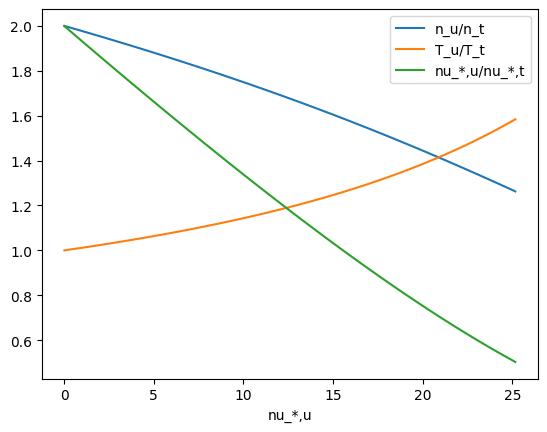

In [45]:
Tu = lambda nut,K: (1+2*nut/K)**(2/7)
nu = lambda nut,K: 2*(1+2*nut/K)**(-2/7)
nuu = lambda nut,K: 2*nut/(1+2*nut/K)**(6/7)

nut = np.linspace(0.01,50,100)

K = 5*5
plt.figure()
plt.plot(nuu(nut,K),nu(nut,K), label='n_u/n_t')
plt.plot(nuu(nut,K),Tu(nut,K), label='T_u/T_t')
plt.plot(nuu(nut,K),nuu(nut,K)/nut,label='nu_*,u/nu_*,t')
#plt.plot(nuu(nut,K),nuu(nut,K)/2,'k:',label='nu_*,u/2')
plt.xlabel('nu_*,u')
plt.legend()